# Quantum Interior-Point Portfolio Optimization
### Applications of Quantum Computing — Workshop Tutorial
*Based on: Kerenidis, Prakash & Szilágyi (2021) — "Quantum Algorithms for Portfolio Optimization"*

---

**Learning objectives**
1. Formulate portfolio optimisation as a linear system and solve it with **HHL** — the direct quantum approach.
2. Recognise *why* real-world constraints (no short-selling, allocation caps) break the direct HHL approach.
3. Understand how the paper reformulates the problem as a **Second-Order Cone Program (SOCP)**.
4. Run a simulated **Quantum IPM** that uses HHL as a subroutine inside an Interior-Point loop.
5. Compare three solvers: Classical CVXPY · Unconstrained HHL · Quantum IPM.

**Duration**: ~45 minutes | **Format**: read → run → discuss


> **Self-contained notebook** — the first code cell installs all required packages automatically.
> **Data**: live market data via `yfinance` (internet required).
> An **offline fallback** block is provided in § 1 for air-gapped environments.


## 0 · Setup

In [1]:
import subprocess, sys

pkgs = [
    "qiskit>=2.4.0",
    "cvxpy>=1.4.0",
    "yfinance>=0.2.0",
    "numpy>=1.26",
    "scipy>=1.13",
    "matplotlib>=3.8",
    "seaborn>=0.13",
    "pylatexenc",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)
print("✅ All packages ready")


✅ All packages ready


In [2]:
import importlib, time, warnings
import numpy as np
import pandas as pd
import scipy.linalg
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import cvxpy as cp
import yfinance as yf

from qiskit import QuantumCircuit, QuantumRegister
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import QFTGate, RYGate

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12})

CONFIG = {
    "tickers":               ["AAPL", "MSFT", "NVDA", "AMZN", "TLT"],
    "start_date":            "2024-01-01",
    "end_date":              "2024-12-31",
    "trading_days_per_year": 252,
    "total_allocation":      1.0,
    "target_return":         0.30,        # annualised; feasible given 2024 returns
    "max_weight":            0.35,        # diversification cap per asset
    "default_min_weight":    0.0,         # long-only
    "custom_bounds":         {},
    # ── Optional sector-level constraint (uncomment to activate) ──────────────
    # "extra_inequalities": [({"AAPL": 1.0, "MSFT": 1.0}, 0.50)],  # AAPL+MSFT ≤ 50%
    "extra_inequalities":    [],
    # ── Quantum solver controls ───────────────────────────────────────────────
    "quantum_hhl_n_clk":     4,           # QPE clock qubits (research notebook uses 8)
    "quantum_hhl_pad_eig":   0.1,         # eigenvalue floor to avoid division by zero
    "quantum_ipm_use_adaptive_step": True,
}

print("Package versions:")
for pkg in ["numpy", "scipy", "cvxpy", "yfinance", "qiskit", "matplotlib", "seaborn"]:
    try:
        print(f"  {pkg}: {importlib.import_module(pkg).__version__}")
    except Exception as e:
        print(f"  {pkg}: not found ({e})")
print("\n✅ Imports OK")


Package versions:
  numpy: 2.2.6
  scipy: 1.13.1
  cvxpy: 1.8.2
  yfinance: 0.2.58
  qiskit: 2.4.1
  matplotlib: 3.8.4
  seaborn: 0.13.2

✅ Imports OK


## 1 · Portfolio Universe

We use **live 2024 market data** for five assets: four tech/e-commerce equities plus a bond ETF.

| Ticker | Name | Role |
|--------|------|------|
| AAPL | Apple | Large-cap tech |
| MSFT | Microsoft | Large-cap tech |
| NVDA | NVIDIA | High-growth GPU / AI |
| AMZN | Amazon | E-commerce / cloud |
| TLT  | iShares 20+ Yr Treasury | Bond proxy — low risk, low return |

> An **offline fallback** block follows — skip it if Cell 6 ran successfully.


In [3]:
print("Downloading 2024 price data via yfinance…")
tickers = CONFIG["tickers"]

raw = yf.download(
    tickers,
    start=CONFIG["start_date"],
    end=CONFIG["end_date"],
    auto_adjust=True,
    progress=False,
)

if isinstance(raw.columns, pd.MultiIndex):
    prices = raw["Close"].copy()
else:
    prices = raw.copy()

prices = prices.dropna(how="all").ffill().dropna(axis=1)
prices = prices[[t for t in tickers if t in prices.columns]]

returns_daily = prices.pct_change().dropna()
T       = CONFIG["trading_days_per_year"]
mu_vec  = (returns_daily.mean() * T).values
cov_mat = (returns_daily.cov()  * T).values + np.eye(len(prices.columns)) * 1e-8
assets  = list(prices.columns)
n       = len(assets)

print(f"✅  {prices.shape[0]} trading days  |  {n} assets")
display(
    pd.DataFrame({"Annual Return (2024)": mu_vec}, index=assets)
      .style.format("{:.1%}")
)


✅  251 trading days  |  5 assets


,Annual Return (2024)
AAPL,33.9%
MSFT,16.4%
NVDA,119.6%
AMZN,43.2%
TLT,-6.3%


In [4]:
# ── OFFLINE FALLBACK ─────────────────────────────────────────────────────────
# Only run this cell if yfinance failed above.
# Generates synthetic mu / cov matching the same tickers (rough 2024 proxies).
# ─────────────────────────────────────────────────────────────────────────────

if "mu_vec" not in dir() or mu_vec is None:
    print("⚠️  Using synthetic fallback (no internet connection detected).")
    assets  = CONFIG["tickers"]
    n       = len(assets)
    rng     = np.random.default_rng(42)
    mu_vec  = np.array([0.34, 0.16, 1.20, 0.43, 0.04])   # rough 2024 estimates
    F       = rng.standard_normal((n, 2)) * 0.15
    D       = np.diag(np.abs(rng.standard_normal(n)) * 0.05 + 0.02)
    cov_mat = F @ F.T + D
    cov_mat = (cov_mat + cov_mat.T) / 2 + np.eye(n) * 1e-8
    print("Synthetic µ:", dict(zip(assets, np.round(mu_vec, 2))))
else:
    print("✅  Live data already loaded — skipping offline fallback.")


✅  Live data already loaded — skipping offline fallback.


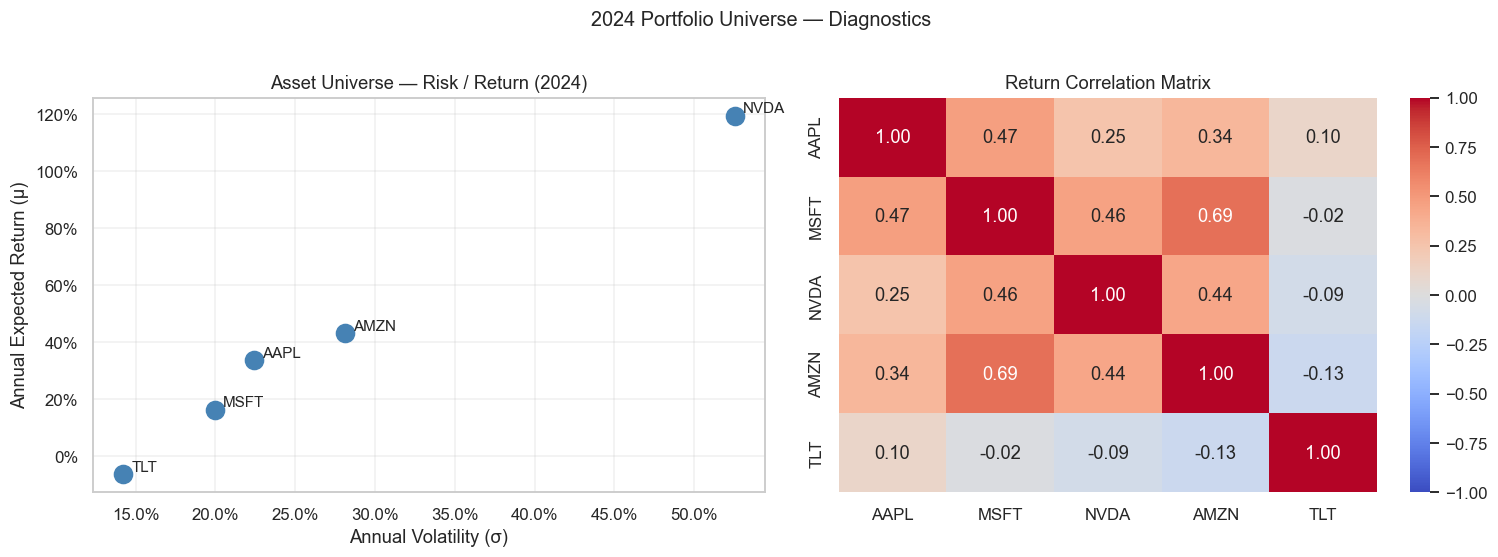

In [5]:
vols = np.sqrt(np.diag(cov_mat))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: risk / return scatter
axes[0].scatter(vols, mu_vec, s=140, color="steelblue", zorder=3)
for i, a in enumerate(assets):
    axes[0].annotate(a, (vols[i] + 0.005, mu_vec[i] + 0.01), fontsize=10)
axes[0].set_xlabel("Annual Volatility (σ)")
axes[0].set_ylabel("Annual Expected Return (µ)")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axes[0].set_title("Asset Universe — Risk / Return (2024)")
axes[0].grid(True, alpha=0.3)

# Right: return correlation heatmap
corr_diag = np.diag(1.0 / np.sqrt(np.diag(cov_mat)))
corr_norm = corr_diag @ cov_mat @ corr_diag
sns.heatmap(
    pd.DataFrame(corr_norm, index=assets, columns=assets),
    annot=True, fmt=".2f", cmap="coolwarm",
    ax=axes[1], vmin=-1, vmax=1,
)
axes[1].set_title("Return Correlation Matrix")

plt.suptitle("2024 Portfolio Universe — Diagnostics", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2 · Classical Baseline — CVXPY SOCP

Before going quantum, we solve the **fully constrained problem classically** with CVXPY + CLARABEL.
This gives us the ground-truth optimal portfolio to compare against.

**Constraints enforced:**

| Constraint | Meaning |
|---|---|
| `sum(w) = 1` | Fully-invested budget |
| `w ≥ 0` | **No short-selling** |
| `w ≤ max_weight` | Diversification cap |
| `µᵀw ≥ target_return` | Minimum return target |
| *(optional)* `sector_group ≤ cap` | Sector concentration limit — see `extra_inequalities` in CONFIG |


In [6]:
def solve_classical_portfolio_cvxpy(mu, Cov, target_return, max_w,
                                     extra_ineq=None, asset_names=None):
    if extra_ineq is None:
        extra_ineq = []
    if asset_names is None:
        asset_names = [f"a{i}" for i in range(len(mu))]
    n_a = len(mu)
    w = cp.Variable(n_a)
    cons = [
        cp.sum(w) == 1.0,
        w >= 0.0,
        w <= max_w,
        mu @ w >= target_return,
    ]
    for coeffs, rhs_val in extra_ineq:
        row = np.array([coeffs.get(a, 0.0) for a in asset_names], dtype=float)
        cons.append(row @ w <= rhs_val)
    prob = cp.Problem(cp.Minimize(cp.quad_form(w, cp.psd_wrap(Cov))), cons)
    try:
        prob.solve(solver=cp.CLARABEL, verbose=False)
        ok = prob.status in ("optimal", "optimal_inaccurate")
        return (w.value if ok else None), ok, prob.status
    except Exception as e:
        return None, False, str(e)


t0 = time.time()
w_cls, cls_ok, cls_status = solve_classical_portfolio_cvxpy(
    mu_vec, cov_mat,
    CONFIG["target_return"], CONFIG["max_weight"],
    CONFIG["extra_inequalities"], assets,
)
elapsed = time.time() - t0

if cls_ok:
    ret_cls = float(w_cls @ mu_vec)
    var_cls = float(w_cls @ cov_mat @ w_cls)
    std_cls = float(np.sqrt(var_cls))
    print(f"✅ Solved in {elapsed * 1000:.1f} ms")
    print(f"   Expected return  : {ret_cls:.2%}")
    print(f"   Annual variance  : {var_cls:.4f}")
    print(f"   Annual volatility: {std_cls:.2%}")
    display(
        pd.DataFrame({"asset": assets, "weight": w_cls})
          .sort_values("weight", ascending=False).reset_index(drop=True)
          .style.format({"weight": "{:.1%}"})
    )
else:
    print(f"❌ Solver failed: {cls_status}")
    print("   Tip: lower CONFIG['target_return'] or raise CONFIG['max_weight']")
    w_cls = np.zeros(n)
    cls_ok = False


✅ Solved in 6.4 ms
   Expected return  : 30.00%
   Annual variance  : 0.0217
   Annual volatility: 14.73%


,asset,weight
0,TLT,35.0%
1,AAPL,32.4%
2,AMZN,18.8%
3,NVDA,10.5%
4,MSFT,3.3%


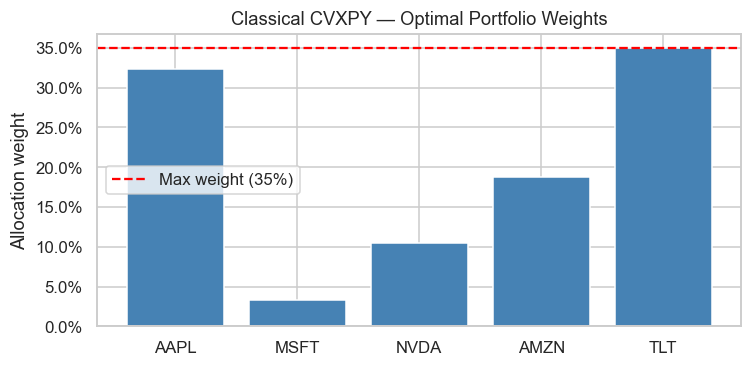

In [7]:
if cls_ok:
    fig, ax = plt.subplots(figsize=(7, 3.5))
    colors = ["steelblue" if w >= 0 else "tomato" for w in w_cls]
    ax.bar(assets, w_cls, color=colors, edgecolor="white")
    ax.axhline(CONFIG["max_weight"], color="red", linestyle="--",
               label=f"Max weight ({CONFIG['max_weight']:.0%})")
    ax.set_ylabel("Allocation weight")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_title("Classical CVXPY — Optimal Portfolio Weights")
    ax.legend()
    plt.tight_layout()
    plt.show()


## 3 · Quantum Theory Bridge

### 3.1  When HHL Works Directly

The **HHL algorithm** (Harrow–Hassidim–Lloyd, 2009) solves `Ax = b` in time
**O(log n · κ² / ε)**  vs the classical  **O(n · κ / ε)** — a potential exponential speedup.

If portfolio optimisation had *only* equality constraints (budget + return target), the KKT optimality conditions collapse to a single linear system:

$$
\underbrace{\begin{pmatrix} 2\Sigma & A_{\text{eq}}^\top \\ A_{\text{eq}} & 0 \end{pmatrix}}_{K}
\begin{pmatrix} w \\ \lambda \end{pmatrix}
=
\begin{pmatrix} 0 \\ b \end{pmatrix}
$$

HHL can solve this directly in one shot.  **But real portfolios need inequality constraints.**

### 3.2  Why HHL Breaks with Inequalities

Adding `w ≥ 0` and `w ≤ w_max` makes the problem a **constrained quadratic program** — no longer a single linear system.  It requires *iterative* refinement, not one shot.

### 3.3  The Paper's Fix: Quantum IPM

**Kerenidis et al. (2021)** reformulate as a **Second-Order Cone Program (SOCP)** and quantize the classical interior-point loop by replacing each Newton-step linear solve with HHL.

| Step | Classical | Quantum |
|------|-----------|---------|
| Newton system solve | Cholesky **O(n³)** | HHL Phase Estimation |
| # iterations | O(√r) | O(√r) |
| **Total complexity** | **O(n³·√r)** | **O(n·κζ·√r·log n)** |

*r = number of cone constraints, κ = condition number, ζ ≤ √n.*

### 3.4  SOCP Constraint Equivalence

| Classical constraint | SOCP cone form |
|---|---|
| Minimise `wᵀΣw` | Minimise `t₀`  subject to  `(t₀, Mw) ∈ L^m` |
| `µᵀw ≥ R` | `µᵀx = R` (equality — binds at optimum) |
| `sum(w) = 1` | `1ᵀx = 1` |
| `w ≥ 0` | `xᵢ ∈ L⁰` (1-D non-negative Lorentz cone) |
| `w ≤ w_max` | `xᵢ + sᵢ = w_max`,  `sᵢ ∈ L⁰` |


## 4 · SOCP Reformulation

Introduce **M** such that Σ = MᵀM via eigendecomposition.
The SOCP variable vector is:

$$v = [t_0;\; \tilde{t};\; x;\; s_{\max}]$$

- **t₀** ∈ ℝ — risk bound scalar
- **t̃** ∈ ℝᵐ — Lorentz norm vector (enforces ‖Mw‖₂ ≤ t₀)
- **x** ∈ ℝⁿ — portfolio weights
- **s_max** ∈ ℝⁿ — slack variables for diversification caps

The **Lorentz cone**: $L^m = \{(t_0, \tilde{t}) \in \mathbb{R}^{m+1} \mid \|\tilde{t}\|_2 \le t_0\}$


In [ ]:
# Build M s.t. Sigma = M^T M  (eigendecomposition)
eigvals, eigvecs = np.linalg.eigh(cov_mat)
eigvals_pos = np.clip(eigvals, 0.0, None)
M_mat = np.diag(np.sqrt(eigvals_pos)) @ eigvecs.T

recon_err = np.linalg.norm(cov_mat - M_mat.T @ M_mat, ord="fro")
print(f"Frobenius reconstruction error ‖Σ − MᵀM‖_F = {recon_err:.2e}")

if cls_ok:
    q  = float(w_cls @ cov_mat @ w_cls)
    nq = float(np.linalg.norm(M_mat @ w_cls) ** 2)
    print(f"  wᵀΣw  = {q:.8f}")
    print(f"  ‖Mw‖² = {nq:.8f}")
    print(f"  Δ     = {abs(q - nq):.2e}  ✅  (should be ≈ machine epsilon)")


Frobenius reconstruction error ‖Σ − MᵀM‖_F = 2.79e-16
  wᵀΣw  = 0.02170052
  ‖Mw‖² = 0.02170052
  Δ     = 0.00e+00  ✅  (should be ≈ machine epsilon)


## 5 · The HHL Sub-Routine

HHL solves `K|dz⟩ = |r⟩` using a four-stage quantum circuit:

```
Stage 1 — State Preparation    encode  |r/‖r‖⟩  into the system register
Stage 2 — Phase Estimation     QPE maps eigenvalues λᵢ of K to clock-register phases
Stage 3 — Eigenvalue Inversion controlled-RY rotates ancilla by arcsin(C/λᵢ)  →  1/λᵢ
Stage 4 — Uncompute            reverse QPE; post-select ancilla = |1⟩ → extract solution
```

**Circuit registers:**

| Register | Size | Role |
|----------|------|------|
| `sys` | n_sys qubits | Holds the state vector |
| `clk` | n_clk qubits | QPE precision — more qubits → sharper eigenvalue resolution |
| `anc` | 1 qubit | Ancilla for eigenvalue inversion; post-select on `|1⟩` |

With `n_clk = 4` and a 5-asset problem the circuit uses **≈ 11 qubits** (fast to simulate).


In [9]:
last_qc = None   # global — captures the circuit from the most recent HHL call


def quantum_newton_solver(K_mat, r_vec, n_clk=4, pad_eig=0.1):
    """
    Simulated HHL-style solver for the linear system  K @ dz = r.

    Parameters
    ----------
    K_mat   : (d, d) matrix (will be symmetrised internally)
    r_vec   : (d,)  right-hand side
    n_clk   : number of QPE clock qubits (precision ≈ 2^{-n_clk})
    pad_eig : small value added to diagonal padding to keep eigenvalues away from 0

    Returns
    -------
    dz : (d,) approximate solution vector
    """
    global last_qc

    K_herm = (K_mat + K_mat.T) / 2
    dim    = len(K_herm)
    n_sys  = int(np.ceil(np.log2(dim)))
    dim_pad = 2 ** n_sys

    # Pad to 2^n_sys with a small identity term (keeps eigenvalues positive)
    K_pad = np.eye(dim_pad) * pad_eig
    K_pad[:dim, :dim] = K_herm

    r_pad  = np.zeros(dim_pad)
    r_pad[:len(r_vec)] = r_vec
    r_norm = np.linalg.norm(r_pad)
    if r_norm < 1e-12:
        return np.zeros(dim)
    r_normalized = r_pad / r_norm

    # Calibrate evolution time so that max eigenvalue phase < π/2
    eig_max = np.max(np.abs(np.linalg.eigvalsh(K_pad)))
    t = np.pi / (eig_max * 1.2)

    qr_sys = QuantumRegister(n_sys, "sys")
    qr_clk = QuantumRegister(n_clk, "clk")
    qr_anc = QuantumRegister(1,     "anc")
    qc     = QuantumCircuit(qr_sys, qr_clk, qr_anc)
    last_qc = qc

    # ── Stage 1: State Preparation ────────────────────────────────────────
    qc.initialize(r_normalized, qr_sys)

    # ── Stage 2: Phase Estimation ─────────────────────────────────────────
    qc.h(qr_clk)
    for i in range(n_clk):
        power  = 2 ** i
        U_pow  = Operator(scipy.linalg.expm(1j * K_pad * t * power))
        cU     = U_pow.to_instruction().control(1)
        qc.append(cU, [qr_clk[i]] + list(qr_sys))
    qc.append(QFTGate(n_clk).inverse(), qr_clk)

    # ── Stage 3: Eigenvalue Inversion ─────────────────────────────────────
    C = 0.05  # scale factor; C/λᵢ is the rotation angle denominator
    for x in range(1, 2 ** n_clk):
        bin_str = format(x, f"0{n_clk}b")
        phase   = x / (2 ** n_clk)
        if phase >= 0.5:
            phase -= 1.0
        lmbda = phase * (2 * np.pi) / t
        if np.abs(lmbda) < 1e-5:
            continue
        ratio = C / lmbda
        if np.abs(ratio) > 1.0:
            ratio = np.sign(ratio)
        theta = 2 * np.arcsin(ratio)
        mcry  = RYGate(theta).control(n_clk, ctrl_state=bin_str)
        qc.append(mcry, list(qr_clk) + [qr_anc[0]])

    # ── Stage 4: Uncompute ────────────────────────────────────────────────
    qc.append(QFTGate(n_clk), qr_clk)
    for i in reversed(range(n_clk)):
        power    = 2 ** i
        U_pow_inv = Operator(scipy.linalg.expm(-1j * K_pad * t * power))
        cU_inv   = U_pow_inv.to_instruction().control(1)
        qc.append(cU_inv, [qr_clk[i]] + list(qr_sys))
    qc.h(qr_clk)

    # ── Extract solution from statevector ─────────────────────────────────
    sv        = Statevector(qc)
    half_dim  = 2 ** (n_sys + n_clk)
    raw_data  = sv.data[half_dim: half_dim + dim_pad]
    dz        = np.real(raw_data)[:dim] * (r_norm / C)
    return dz


print("✅  quantum_newton_solver defined")
print("    Tip: change CONFIG['quantum_hhl_n_clk'] for higher QPE precision (research notebook uses 8)")


✅  quantum_newton_solver defined
    Tip: change CONFIG['quantum_hhl_n_clk'] for higher QPE precision (research notebook uses 8)


Equality-only KKT: 7×7
Circuit registers: sys=3 qubits | clk=4 qubits | anc=1 qubit
Total qubits: 8

Building and visualising HHL circuit…
Circuit depth: 27 | Gates: 34


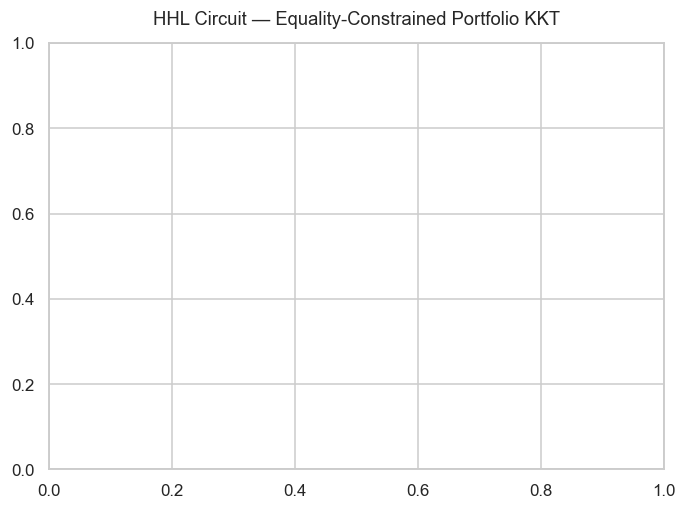

In [10]:
# Build equality-only KKT: K = [[2Σ, Aᵀ], [A, 0]],  rhs = [0,…,0, 1, target_return]
H_eq  = 2 * cov_mat
A_eq  = np.vstack([np.ones((1, n)), mu_vec.reshape(1, n)])
K_eq  = np.block([[H_eq, A_eq.T], [A_eq, np.zeros((2, 2))]])
rhs_eq = np.concatenate([np.zeros(n), [1.0, CONFIG["target_return"]]])

n_clk_demo = CONFIG["quantum_hhl_n_clk"]
n_sys_demo = int(np.ceil(np.log2(K_eq.shape[0])))
print(f"Equality-only KKT: {K_eq.shape[0]}×{K_eq.shape[1]}")
print(f"Circuit registers: sys={n_sys_demo} qubits | clk={n_clk_demo} qubits | anc=1 qubit")
print(f"Total qubits: {n_sys_demo + n_clk_demo + 1}")
print("\nBuilding and visualising HHL circuit…")

_ = quantum_newton_solver(K_eq, rhs_eq,
                           n_clk=n_clk_demo,
                           pad_eig=CONFIG["quantum_hhl_pad_eig"])

print(f"Circuit depth: {last_qc.depth()} | Gates: {last_qc.size()}")
fig = last_qc.draw("mpl", style="iqp", fold=40)
plt.title("HHL Circuit — Equality-Constrained Portfolio KKT", pad=12)
plt.tight_layout()
plt.show()


## 6 · Unconstrained Portfolio via HHL

We now **run** HHL on the equality-only KKT system.
No positivity constraint, no caps — this is the pure Markowitz optimum with only budget and return equalities.


In [11]:
print("Solving equality-constrained KKT with HHL…")
t0 = time.time()
dz_hhl  = quantum_newton_solver(K_eq, rhs_eq,
                                  n_clk=CONFIG["quantum_hhl_n_clk"],
                                  pad_eig=CONFIG["quantum_hhl_pad_eig"])
elapsed = time.time() - t0
w_hhl_raw = dz_hhl[:n]
print(f"✅ HHL solved in {elapsed:.2f} s")


Solving equality-constrained KKT with HHL…
✅ HHL solved in 0.12 s


In [12]:
df_hhl = pd.DataFrame({
    "Asset": assets,
    "HHL weight (raw)": w_hhl_raw,
    "Short position?": ["⚠️ YES" if v < -1e-4 else "—" for v in w_hhl_raw],
})
print("Unconstrained HHL portfolio weights:")
display(df_hhl.style.format({"HHL weight (raw)": "{:.2%}"}))

n_shorts = (w_hhl_raw < -1e-4).sum()
if n_shorts > 0:
    short_names = [a for a, v in zip(assets, w_hhl_raw) if v < -1e-4]
    print(f"\n⚠️  {n_shorts} short position(s) detected: {short_names}")
    print("   Negative weights mean BORROWING and SELLING those assets.")
    print("   Mathematically valid without constraints; problematic for long-only mandates.")
else:
    print("\nℹ️  No shorts in this instance — but HHL has NO mechanism to PREVENT them.")
    print("   For a higher target return they would appear. Quantum IPM guarantees non-negativity.")

print(f"\nSum of weights: {w_hhl_raw.sum():.4f}  (should be ≈ 1 — equality was enforced)")
print("Min weight    :", f"{w_hhl_raw.min():.2%}")


Unconstrained HHL portfolio weights:


,Asset,HHL weight (raw),Short position?
0,AAPL,19.66%,—
1,MSFT,20.88%,—
2,NVDA,8.29%,—
3,AMZN,17.95%,—
4,TLT,23.99%,—



ℹ️  No shorts in this instance — but HHL has NO mechanism to PREVENT them.
   For a higher target return they would appear. Quantum IPM guarantees non-negativity.

Sum of weights: 0.9076  (should be ≈ 1 — equality was enforced)
Min weight    : 8.29%


## 7 · Quantum Interior-Point Method

To enforce **all** constraints we need an iterative solver.
The paper uses a **short-step interior-point method** (IPM) where each Newton step is solved by HHL.

### Newton system at each IPM iteration (Eq. 6 from the paper)

$$
\begin{pmatrix}
0 & A^\top & I \\
A & 0 & 0 \\
\text{Arw}(s) & 0 & \text{Arw}(x)
\end{pmatrix}
\begin{pmatrix} \Delta x \\ \Delta y \\ \Delta s \end{pmatrix}
=
\begin{pmatrix} r_d \\ r_p \\ r_c \end{pmatrix}
$$

**Arw(v)** is the *arrowhead* matrix of v — the Jordan-algebra product operator for Lorentz cones.
The **duality gap** ν = xᵀs / r shrinks by factor σ ≈ 1 − 0.1/√r every iteration.


In [13]:
def arrowhead_product(v, m, n):
    """
    Block-diagonal arrowhead matrix for the cone product  L^m × (L^0)^{2n}.

    For L^m cone:  Arw(t) = [[t₀, t̃ᵀ], [t̃, t₀·I]]
    For L^0 cones: Arw(xᵢ) = diag(xᵢ)  (scalar — just the value itself)
    """
    t   = v[:1 + m]
    x_s = v[1 + m:]

    t0    = t[0]
    t_bar = t[1:].reshape(-1, 1)

    Arw_t = np.vstack([
        np.hstack([[[t0]], t_bar.T]),
        np.hstack([t_bar, t0 * np.eye(m)]),
    ])
    Arw_x_s = np.diag(x_s)

    Arw = np.zeros((len(v), len(v)))
    Arw[:1 + m, :1 + m] = Arw_t
    Arw[1 + m:, 1 + m:] = Arw_x_s
    return Arw


print("✅  arrowhead_product defined")


✅  arrowhead_product defined


In [14]:
def run_socp_quantum_ipm(mu_vec, M_mat, target_return, max_weight,
                          extra_inequalities=None, assets=None,
                          max_iter=15, tol=1e-3, n_clk=4,
                          use_adaptive_step=True, alpha_fixed=0.5):
    """
    Quantum Interior-Point Method for the Markowitz SOCP.

    At each Newton iteration the full KKT system is solved by quantum_newton_solver
    (the simulated HHL circuit), instead of classical Cholesky.

    Parameters
    ----------
    mu_vec, M_mat      : return vector and covariance square root (Σ = MᵀM)
    target_return      : required annual return (equality binding at optimum)
    max_weight         : per-asset allocation cap (diversification constraint)
    extra_inequalities : list of (dict, rhs) sector constraints
    max_iter, tol      : stopping criteria
    n_clk              : QPE clock qubits (precision)
    use_adaptive_step  : if True, compute max step via fraction-to-boundary rule
    """
    if extra_inequalities is None:
        extra_inequalities = []
    if assets is None:
        assets = [f"a{i}" for i in range(len(mu_vec))]

    n_a     = len(mu_vec)
    m       = M_mat.shape[0]
    n_vars  = 1 + m + 2 * n_a          # [t0; t_tilde; x; s_max]
    r_cones = 1 + 2 * n_a              # 1 Lorentz cone + 2n non-neg cones

    # ── Build equality-constraint matrix A and RHS b ──────────────────────
    # 1) t_tilde − M x = 0
    row1 = np.hstack([np.zeros((m, 1)), -np.eye(m), M_mat, np.zeros((m, n_a))])
    b1   = np.zeros(m)
    # 2) µᵀx = target_return
    row2 = np.hstack([np.zeros((1,1)), np.zeros((1,m)), mu_vec.reshape(1,-1), np.zeros((1,n_a))])
    b2   = np.array([target_return])
    # 3) 1ᵀx = 1  (budget)
    row3 = np.hstack([np.zeros((1,1)), np.zeros((1,m)), np.ones((1,n_a)), np.zeros((1,n_a))])
    b3   = np.array([1.0])
    # 4) x + s_max = w_max  (diversification cap slacks)
    row4 = np.hstack([np.zeros((n_a,1)), np.zeros((n_a,m)), np.eye(n_a), np.eye(n_a)])
    b4   = np.ones(n_a) * max_weight

    rows, bs = [row1, row2, row3, row4], [b1, b2, b3, b4]
    for coeffs, rhs_val in extra_inequalities:
        row = np.array([coeffs.get(a, 0.0) for a in assets], dtype=float)
        rows.append(np.hstack([np.zeros(1+m), row, np.zeros(n_a)]).reshape(1,-1))
        bs.append(np.array([rhs_val]))

    A      = np.vstack(rows)
    b      = np.concatenate(bs)
    c      = np.concatenate([[1.0], np.zeros(m), np.zeros(2 * n_a)])
    n_cons = A.shape[0]
    e_cone = np.concatenate([[1.0], np.zeros(m), np.ones(2 * n_a)])

    # ── Strictly-interior starting point ─────────────────────────────────
    x_orig    = np.ones(n_a) / n_a
    s_max_0   = np.ones(n_a) * max_weight - x_orig
    t_tilde_0 = M_mat @ x_orig
    t0_init   = np.linalg.norm(t_tilde_0) + 1.0
    x  = np.concatenate([[t0_init], t_tilde_0, x_orig, s_max_0])
    y  = np.zeros(n_cons)
    s  = np.ones(n_vars) * 0.5
    s[0] = np.linalg.norm(s[1:1+m]) + 1.0

    gaps = []
    print(f"  {'Iter':>4}  {'Alpha':>8}  {'Duality Gap':>14}")
    print(f"  {'-'*4}  {'-'*8}  {'-'*14}")

    for i in range(max_iter):
        gap_val     = np.dot(x, s) / r_cones
        sigma       = 1.0 - 0.1 / np.sqrt(r_cones)
        mu_barrier  = sigma * gap_val

        Arw_x = arrowhead_product(x, m, n_a)
        Arw_s = arrowhead_product(s, m, n_a)

        # Full KKT Newton system
        K_top    = np.hstack([np.zeros((n_vars, n_vars)), A.T, np.eye(n_vars)])
        K_mid    = np.hstack([A, np.zeros((n_cons, n_cons)), np.zeros((n_cons, n_vars))])
        K_bot    = np.hstack([Arw_s, np.zeros((n_vars, n_cons)), Arw_x])
        KKT_full = np.vstack([K_top, K_mid, K_bot])

        rp  = b - A @ x
        rd  = c - s - A.T @ y
        rc  = mu_barrier * e_cone - Arw_x @ s
        rhs = np.concatenate([rd, rp, rc])

        # ── Quantum Newton step ───────────────────────────────────────────
        dz = quantum_newton_solver(KKT_full, rhs, n_clk=n_clk)
        dx = dz[:n_vars]
        dy = dz[n_vars:n_vars + n_cons]
        ds = dz[-n_vars:]

        # ── Adaptive step-size (fraction-to-boundary) ─────────────────────
        if use_adaptive_step:
            # L⁰ cones (primal weights x[1+m:] and slacks)
            alpha_L0_x = 1.0
            idx = np.where(dx[1+m:] < 0)[0]
            if len(idx) > 0:
                alpha_L0_x = float(np.min(-x[1+m:][idx] / dx[1+m:][idx]))
            alpha_L0_s = 1.0
            idx = np.where(ds[1+m:] < 0)[0]
            if len(idx) > 0:
                alpha_L0_s = float(np.min(-s[1+m:][idx] / ds[1+m:][idx]))
            alpha_L0 = min(alpha_L0_x, alpha_L0_s)

            # L^m cone (Lorentz cone on t0, t_tilde)
            dx0, dt    = dx[0], dx[1:1+m]
            t0v, ttv   = x[0], x[1:1+m]
            a_p = dx0**2 - np.dot(dt, dt)
            b_p = 2 * (t0v * dx0 - np.dot(ttv, dt))
            c_p = t0v**2 - np.dot(ttv, ttv)
            alpha_Lm_x = 1.0
            if a_p < 0 or b_p < 0:
                rts = [r.real for r in np.roots([a_p, b_p, c_p])
                       if np.isreal(r) and r.real > 0]
                if rts:
                    alpha_Lm_x = min(rts)

            ds0, dst   = ds[0], ds[1:1+m]
            s0v, stv   = s[0], s[1:1+m]
            a_d = ds0**2 - np.dot(dst, dst)
            b_d = 2 * (s0v * ds0 - np.dot(stv, dst))
            c_d = s0v**2 - np.dot(stv, stv)
            alpha_Lm_s = 1.0
            if a_d < 0 or b_d < 0:
                rts = [r.real for r in np.roots([a_d, b_d, c_d])
                       if np.isreal(r) and r.real > 0]
                if rts:
                    alpha_Lm_s = min(rts)

            alpha = min(1.0, 0.95 * min(alpha_L0, alpha_Lm_x, alpha_Lm_s))
        else:
            alpha = alpha_fixed

        x += alpha * dx
        y += alpha * dy
        s += alpha * ds

        # Maintain strict feasibility
        x[0]     = max(x[0], np.linalg.norm(x[1:1+m]) + 1e-4)
        x[1+m:]  = np.maximum(x[1+m:], 1e-6)
        s[0]     = max(s[0], np.linalg.norm(s[1:1+m]) + 1e-4)
        s[1+m:]  = np.maximum(s[1+m:], 1e-6)

        gap_val = abs(np.dot(x, s) / r_cones)
        gaps.append(gap_val)
        print(f"  {i:>4}  {alpha:>8.4f}  {gap_val:>14.6f}")

        if gap_val < tol:
            print(f"\n  ✅ Converged in {i+1} iterations (gap = {gap_val:.2e})")
            break

    w_opt = x[1+m:1+m+n_a]
    w_opt = np.maximum(w_opt, 0.0)
    return w_opt / (w_opt.sum() + 1e-14), gaps


print("✅  run_socp_quantum_ipm defined")


✅  run_socp_quantum_ipm defined


In [15]:
print("Running Quantum IPM  (n_clk=4, 5 assets — expect ~1–3 min)\n")
t_start = time.time()

w_qipm, ipm_gaps = run_socp_quantum_ipm(
    mu_vec, M_mat,
    target_return      = CONFIG["target_return"],
    max_weight         = CONFIG["max_weight"],
    extra_inequalities = CONFIG["extra_inequalities"],
    assets             = assets,
    max_iter           = 15,
    tol                = 1e-3,
    n_clk              = CONFIG["quantum_hhl_n_clk"],
    use_adaptive_step  = CONFIG["quantum_ipm_use_adaptive_step"],
)
elapsed_qipm = time.time() - t_start

ret_qipm = float(w_qipm @ mu_vec)
var_qipm = float(w_qipm @ cov_mat @ w_qipm)
std_qipm = float(np.sqrt(var_qipm))

print(f"\n⏱  Quantum IPM finished in {elapsed_qipm:.1f} s")
print(f"   Expected return  : {ret_qipm:.2%}")
print(f"   Annual variance  : {var_qipm:.4f}")
print(f"   Annual volatility: {std_qipm:.2%}")


Running Quantum IPM  (n_clk=4, 5 assets — expect ~1–3 min)

  Iter     Alpha     Duality Gap
  ----  --------  --------------
     0    1.0000        0.131539
     1    0.9500        0.104739
     2    1.0000        0.094649
     3    1.0000        0.090760
     4    1.0000        0.088612
     5    1.0000        0.087143
     6    1.0000        0.085864
     7    1.0000        0.084657
     8    1.0000        0.083486
     9    1.0000        0.082344
    10    1.0000        0.081230
    11    1.0000        0.080144
    12    1.0000        0.079089
    13    1.0000        0.078064
    14    1.0000        0.077070

⏱  Quantum IPM finished in 232.5 s
   Expected return  : 32.92%
   Annual variance  : 0.0265
   Annual volatility: 16.29%


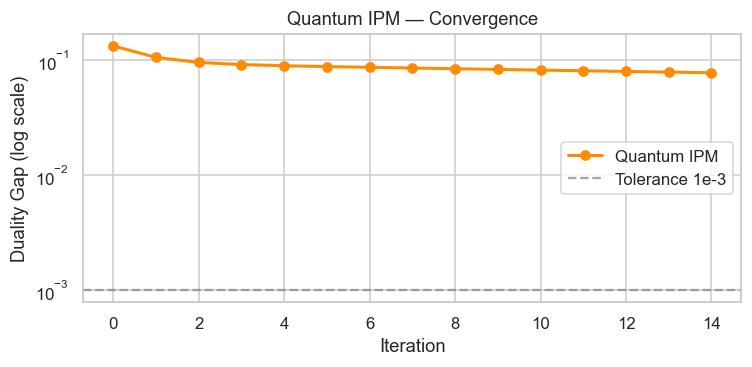

In [16]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.semilogy(ipm_gaps, marker="o", color="darkorange", linewidth=2, label="Quantum IPM")
ax.axhline(1e-3, color="gray", linestyle="--", alpha=0.7, label="Tolerance 1e-3")
ax.set_xlabel("Iteration")
ax.set_ylabel("Duality Gap (log scale)")
ax.set_title("Quantum IPM — Convergence")
ax.legend()
plt.tight_layout()
plt.show()


HHL circuit from final Newton step:
  11 qubits | depth 27 | 34 gates
  (Same HHL structure as § 5 — applied here to the full SOCP KKT system)



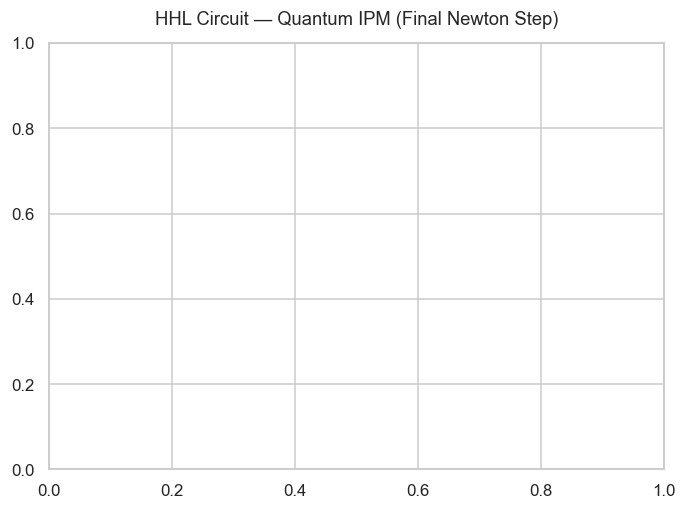

In [17]:
if last_qc is not None:
    print(f"HHL circuit from final Newton step:")
    print(f"  {last_qc.num_qubits} qubits | depth {last_qc.depth()} | {last_qc.size()} gates")
    print("  (Same HHL structure as § 5 — applied here to the full SOCP KKT system)\n")
    fig = last_qc.draw("mpl", style="iqp", fold=40)
    plt.title("HHL Circuit — Quantum IPM (Final Newton Step)", pad=12)
    plt.tight_layout()
    plt.show()


## 8 · Comparison — Three Solvers

| Solver | Constraints enforced | Quantum component |
|--------|---------------------|-------------------|
| Classical CVXPY | All (budget, long-only, cap, return) | None |
| Unconstrained HHL | Budget + return *(equality only)* | HHL direct solve |
| **Quantum IPM** | **All (full SOCP)** | **HHL at each Newton step** |


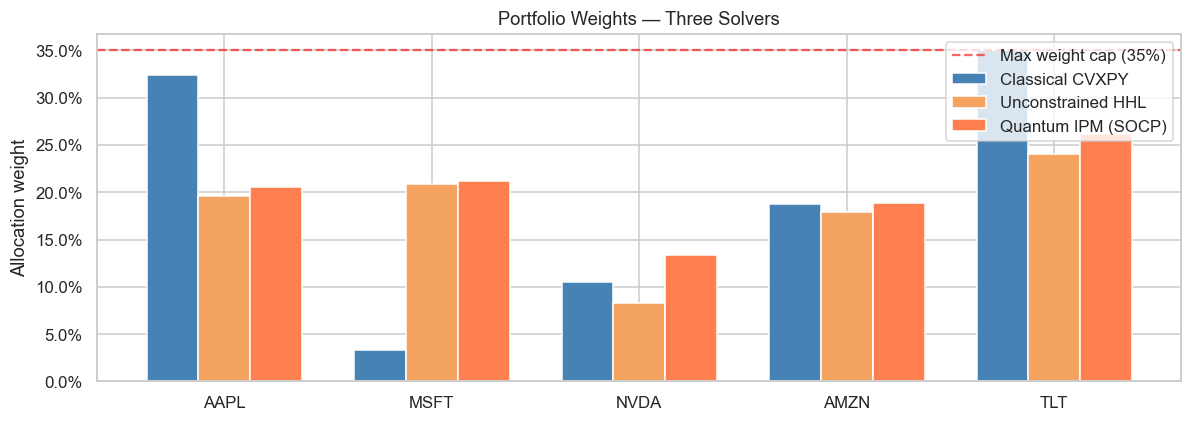


Note: red bars in 'Unconstrained HHL' = short positions (negative weights).
      Quantum IPM and Classical CVXPY both enforce non-negativity.


In [18]:
x_idx = np.arange(n)
width = 0.25

fig, ax = plt.subplots(figsize=(11, 4))

ax.bar(x_idx - width,     w_cls if cls_ok else np.zeros(n),
       width, label="Classical CVXPY",       color="steelblue")
ax.bar(x_idx,             w_hhl_raw,
       width, label="Unconstrained HHL",
       color=["tomato" if v < 0 else "sandybrown" for v in w_hhl_raw])
ax.bar(x_idx + width,     w_qipm,
       width, label="Quantum IPM (SOCP)",    color="coral")

ax.axhline(CONFIG["max_weight"], color="red", linestyle="--", alpha=0.6,
           label=f"Max weight cap ({CONFIG['max_weight']:.0%})")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x_idx)
ax.set_xticklabels(assets)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("Allocation weight")
ax.set_title("Portfolio Weights — Three Solvers")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("\nNote: red bars in 'Unconstrained HHL' = short positions (negative weights).")
print("      Quantum IPM and Classical CVXPY both enforce non-negativity.")


In [19]:
def portfolio_metrics(w, mu, cov, label):
    return {
        "Solver":         label,
        "Exp. Return":    f"{float(w @ mu):.2%}",
        "Variance":       f"{float(w @ cov @ w):.4f}",
        "Volatility":     f"{float(np.sqrt(w @ cov @ w)):.2%}",
        "Min weight":     f"{float(np.min(w)):.2%}",
        "Max weight":     f"{float(np.max(w)):.2%}",
        "Sum of weights": f"{float(np.sum(w)):.4f}",
    }

rows = [
    portfolio_metrics(w_cls if cls_ok else np.zeros(n), mu_vec, cov_mat, "Classical CVXPY"),
    portfolio_metrics(w_hhl_raw,                        mu_vec, cov_mat, "Unconstrained HHL"),
    portfolio_metrics(w_qipm,                           mu_vec, cov_mat, "Quantum IPM (SOCP)"),
]
display(pd.DataFrame(rows).set_index("Solver"))


,Exp. Return,Variance,Volatility,Min weight,Max weight,Sum of weights
Solver,,,,,,
Classical CVXPY,30.00%,0.0217,14.73%,3.34%,35.00%,1.0000
Unconstrained HHL,26.25%,0.0195,13.98%,8.29%,23.99%,0.9076
Quantum IPM (SOCP),32.92%,0.0265,16.29%,13.38%,26.12%,1.0000


## 9 · Out-of-Sample Validation

We test the portfolios on **2025 data** — completely unseen during optimisation.
This mirrors the real deployment workflow: *optimise on training data → deploy on live data*.


✅  yfinance 2025 (249 trading days)

OOS source: yfinance 2025 (249 trading days)


,OOS Total Return,Sharpe (annualised),HHI (concentration)
Solver,,,
Classical CVXPY,13.54%,0.753,0.2747
Unconstrained HHL,13.35%,0.797,0.1789
Quantum IPM (SOCP),15.76%,0.826,0.2084


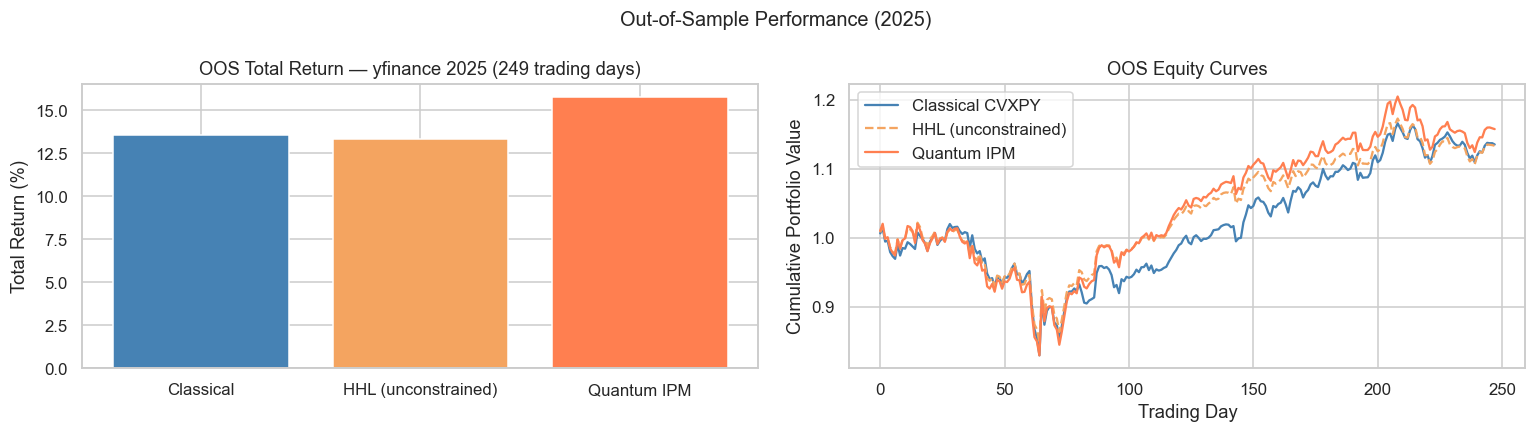

In [20]:
print("Downloading 2025 OOS data…")
oos_source = "unknown"

try:
    test_raw = yf.download(
        assets, start="2025-01-01", end="2025-12-31",
        auto_adjust=True, progress=False,
    )
    if isinstance(test_raw.columns, pd.MultiIndex):
        test_prices = test_raw["Close"][[a for a in assets if a in test_raw["Close"].columns]]
    else:
        test_prices = test_raw
    test_returns = test_prices.pct_change().dropna()
    oos_source   = f"yfinance 2025 ({len(test_prices)} trading days)"
    print(f"✅  {oos_source}")
except Exception as e:
    print(f"⚠️  yfinance failed ({e}) — using synthetic OOS returns.")
    rng_oos      = np.random.default_rng(2025)
    oos_daily    = rng_oos.multivariate_normal(mu_vec / 252, cov_mat / 252, 252)
    test_returns = pd.DataFrame(oos_daily, columns=assets)
    oos_source   = "synthetic (seed=2025)"


def oos_metrics(w, daily_returns, label):
    port       = (daily_returns @ w).values
    total_ret  = float((1 + port).prod() - 1)
    ann_factor = np.sqrt(252)
    sharpe     = float((port.mean() * 252) / (port.std() * ann_factor)) if port.std() > 0 else float("nan")
    hhi        = float(np.sum(w ** 2))
    return {
        "Solver":                label,
        "OOS Total Return":      f"{total_ret:.2%}",
        "Sharpe (annualised)":   f"{sharpe:.3f}",
        "HHI (concentration)":   f"{hhi:.4f}",
    }

metrics_oos = [
    oos_metrics(w_cls if cls_ok else np.zeros(n), test_returns, "Classical CVXPY"),
    oos_metrics(w_hhl_raw,                        test_returns, "Unconstrained HHL"),
    oos_metrics(w_qipm,                           test_returns, "Quantum IPM (SOCP)"),
]
print(f"\nOOS source: {oos_source}")
display(pd.DataFrame(metrics_oos).set_index("Solver"))

# Equity curves
w_cls_plot = w_cls if cls_ok else np.zeros(n)
cls_curve  = (1 + test_returns @ w_cls_plot).cumprod()
qipm_curve = (1 + test_returns @ w_qipm).cumprod()
hhl_curve  = (1 + test_returns @ w_hhl_raw).cumprod()

oos_totals = [(1 + test_returns @ w).prod() - 1
              for w in [w_cls_plot, w_hhl_raw, w_qipm]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(["Classical", "HHL (unconstrained)", "Quantum IPM"],
            [v * 100 for v in oos_totals],
            color=["steelblue", "sandybrown", "coral"])
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Total Return (%)")
axes[0].set_title(f"OOS Total Return — {oos_source}")

axes[1].plot(cls_curve.values,  color="steelblue",   label="Classical CVXPY")
axes[1].plot(hhl_curve.values,  color="sandybrown",  label="HHL (unconstrained)", linestyle="--")
axes[1].plot(qipm_curve.values, color="coral",       label="Quantum IPM")
axes[1].set_xlabel("Trading Day")
axes[1].set_ylabel("Cumulative Portfolio Value")
axes[1].set_title("OOS Equity Curves")
axes[1].legend()

plt.suptitle("Out-of-Sample Performance (2025)", fontsize=13)
plt.tight_layout()
plt.show()


## 10 · Discussion & Extensions

### What did we demonstrate?

| Step | Classical | Quantum |
|------|-----------|---------|
| Problem formulation | SOCP (Lorentz cone) | Identical SOCP |
| Newton step solver | Cholesky **O(n³)** | HHL Phase Estimation |
| Step-size control | Adaptive ratio test | Same |
| Convergence | Exact (machine ε) | Approximate (QPE noise) |

### Is there a quantum advantage *right now*?

**In this simulation — no.** We simulate HHL classically, which is *slower* than Cholesky.
The theoretical speedup (**O(n·κ·√r·log n)** vs **O(n³·√r)**) requires:

1. A fault-tolerant quantum computer with thousands of logical qubits.
2. A large portfolio (**n ≫ 1 000**) where the log n factor dominates.
3. A well-conditioned covariance matrix (bounded κ).

### 🎓 Exercises

1. **Short-selling**: Change `default_min_weight` to `-0.10` and re-run CVXPY. Does the optimal return improve? Does the Quantum IPM produce matching shorts?
2. **Sector constraint**: Uncomment the `extra_inequalities` entry in CONFIG and re-run § 7. Which asset is most constrained?
3. **Higher precision**: Increase `quantum_hhl_n_clk` from `4` → `6`. Do the Quantum IPM weights move closer to the classical baseline?
4. **Scaling**: Add more tickers (e.g. `META`, `GOOGL`, `TSLA`). Observe how circuit depth grows with problem size.

### Further reading

- Kerenidis, Prakash & Szilágyi (2021) — *Quantum Algorithms for Portfolio Optimization*
- Harrow, Hassidim & Lloyd (2009) — *Quantum Algorithm for Linear Systems of Equations*
- Boyd & Vandenberghe — *Convex Optimization* (free PDF) — Chapters 4 & 11


---

## About

This tutorial was developed by **Nadav Ben-Ami** as a workshop replacing the final exam in an Applied Quantum Computing course.

[![GitHub](https://img.shields.io/badge/GitHub-Nadav138-181717?logo=github)](https://github.com/Nadav138) &nbsp;
[![LinkedIn](https://img.shields.io/badge/LinkedIn-Nadav_Ben--Ami-0077B5?logo=linkedin)](https://linkedin.com/in/YOUR_LINKEDIN_HANDLE)

*Based on the full research implementation in [`quantum_ipm_research.ipynb`](quantum_ipm_research.ipynb) in this repository.*
